In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("stress_dataset.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [4]:
df.head()

,Employee_ID,Message,Word_Count,Sentiment_Score,Employee_Role,Department,Stress_Level
0,1,Looking forward to the weekend!,5,0.00,Data Analyst,IT,Low
1,2,Enjoying my work today!,4,0.62,HR Specialist,HR,Low
2,3,Workload is manageable but challenging.,5,0.50,Data Analyst,IT,Medium
3,4,Feeling great about my progress.,5,0.80,Sales Executive,Sales,Low
4,5,Loving the collaborative environment.,4,0.60,Manager,Sales,Low


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 7


In [6]:
print(df.columns)

Index(['Employee_ID', 'Message', 'Word_Count', 'Sentiment_Score',
       'Employee_Role', 'Department', 'Stress_Level'],
      dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Employee_ID      10000 non-null  int64  
 1   Message          10000 non-null  str    
 2   Word_Count       10000 non-null  int64  
 3   Sentiment_Score  10000 non-null  float64
 4   Employee_Role    10000 non-null  str    
 5   Department       10000 non-null  str    
 6   Stress_Level     10000 non-null  str    
dtypes: float64(1), int64(2), str(4)
memory usage: 1.0 MB


In [8]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
Employee_ID        0
Message            0
Word_Count         0
Sentiment_Score    0
Employee_Role      0
Department         0
Stress_Level       0
dtype: int64


In [9]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [10]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (10000, 7)


In [11]:
df["Sentiment_Score"].describe()

count    10000.000000
mean         0.277062
std          0.373968
min         -0.670000
25%          0.000000
50%          0.230000
75%          0.600000
max          1.000000
Name: Sentiment_Score, dtype: float64

In [12]:
print("Minimum sentiment score:",
      df["Sentiment_Score"].min())

print("Maximum sentiment score:",
      df["Sentiment_Score"].max())

print("Average sentiment score:",
      round(df["Sentiment_Score"].mean(), 3))

Minimum sentiment score: -0.67
Maximum sentiment score: 1.0
Average sentiment score: 0.277


In [13]:
def find_sentiment(score):
    
    if score > 0:
        return "Positive"
    
    elif score < 0:
        return "Negative"
    
    else:
        return "Neutral"

In [14]:
df["Sentiment_Category"] = df[
    "Sentiment_Score"
].apply(find_sentiment)

df[
    ["Message", "Sentiment_Score", "Sentiment_Category"]
].head(10)

,Message,Sentiment_Score,Sentiment_Category
0,Looking forward to the weekend!,0.00,Neutral
1,Enjoying my work today!,0.62,Positive
2,Workload is manageable but challenging.,0.50,Positive
3,Feeling great about my progress.,0.80,Positive
4,Loving the collaborative environment.,0.60,Positive
5,Feeling a bit overwhelmed.,0.00,Neutral
6,Multitasking a lot today.,0.00,Neutral
7,"Overloaded with work, this is too much!",0.25,Positive
8,Burned out and exhausted.,-0.40,Negative
9,Feeling great about my progress.,0.80,Positive


In [15]:
sentiment_counts = df[
    "Sentiment_Category"
].value_counts()

print(sentiment_counts)

Sentiment_Category
Positive    5744
Neutral     3215
Negative    1041
Name: count, dtype: int64


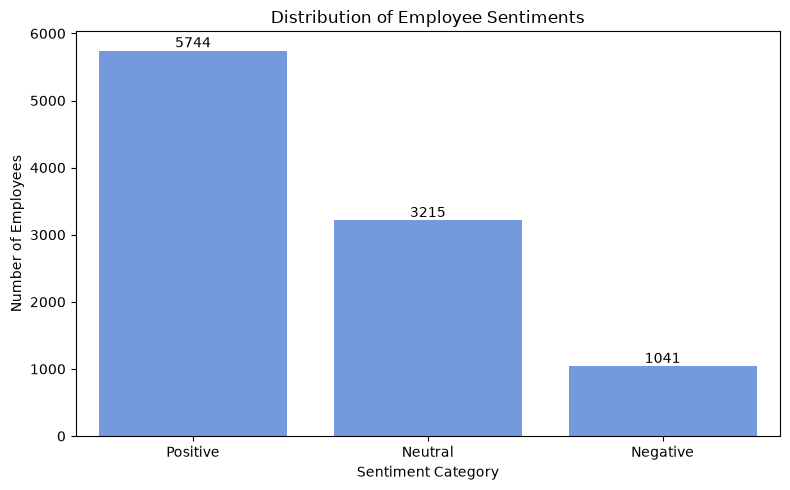

In [16]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Sentiment_Category",
    order=["Positive", "Neutral", "Negative"],
    color="cornflowerblue"
)

plt.title("Distribution of Employee Sentiments")
plt.xlabel("Sentiment Category")
plt.ylabel("Number of Employees")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [17]:
department_sentiment = (
    df.groupby("Department")["Sentiment_Score"]
    .mean()
    .sort_values(ascending=False)
)

print(department_sentiment.round(3))

Department
Sales        0.289
IT           0.284
HR           0.278
Marketing    0.269
Finance      0.264
Name: Sentiment_Score, dtype: float64


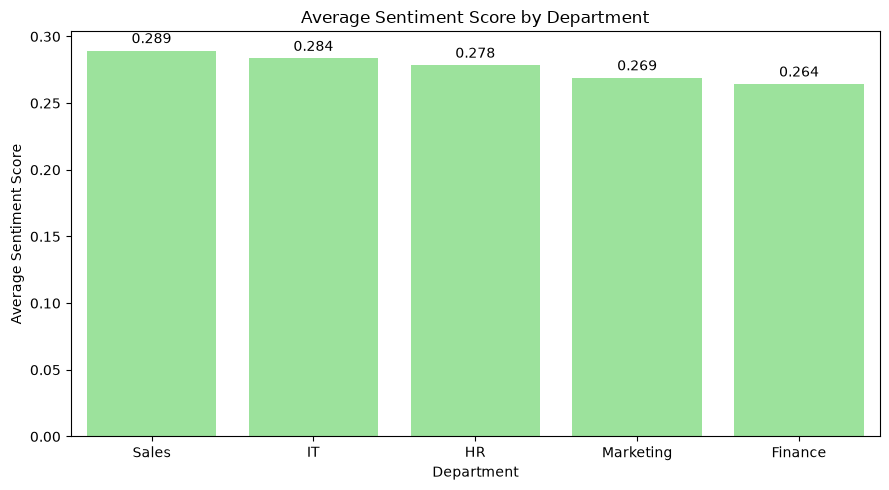

In [18]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=department_sentiment.index,
    y=department_sentiment.values,
    color="lightgreen"
)

plt.title("Average Sentiment Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Sentiment Score")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

In [19]:
department_satisfaction = df.groupby(
    "Department"
).agg(
    Total_Employees=(
        "Employee_ID",
        "count"
    ),
    
    Average_Sentiment=(
        "Sentiment_Score",
        "mean"
    ),
    
    Positive_Rate=(
        "Sentiment_Category",
        lambda x: (x == "Positive").mean() * 100
    ),
    
    Neutral_Rate=(
        "Sentiment_Category",
        lambda x: (x == "Neutral").mean() * 100
    ),
    
    Negative_Rate=(
        "Sentiment_Category",
        lambda x: (x == "Negative").mean() * 100
    )
)

department_satisfaction = (
    department_satisfaction
    .sort_values(
        by="Average_Sentiment",
        ascending=False
    )
)

department_satisfaction.round(2)

,Total_Employees,Average_Sentiment,Positive_Rate,Neutral_Rate,Negative_Rate
Department,,,,,
Sales,2041,0.29,58.94,30.97,10.09
IT,1984,0.28,58.22,31.91,9.88
HR,2044,0.28,57.24,33.17,9.59
Marketing,1950,0.27,56.00,32.21,11.79
Finance,1981,0.26,56.74,32.51,10.75


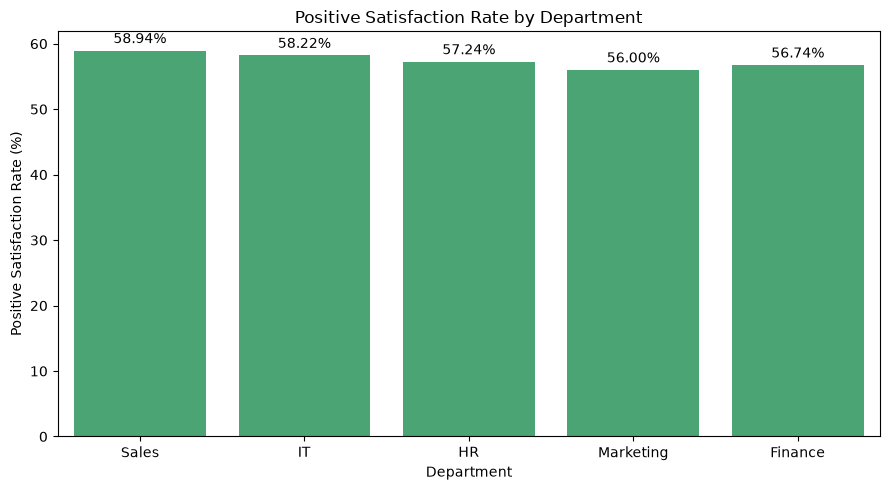

In [20]:
plt.figure(figsize=(9, 5))

plot_data = department_satisfaction.reset_index()

ax = sns.barplot(
    data=plot_data,
    x="Department",
    y="Positive_Rate",
    color="mediumseagreen"
)

plt.title("Positive Satisfaction Rate by Department")
plt.xlabel("Department")
plt.ylabel("Positive Satisfaction Rate (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

In [21]:
highest_department = (
    department_satisfaction[
        "Average_Sentiment"
    ].idxmax()
)

lowest_department = (
    department_satisfaction[
        "Average_Sentiment"
    ].idxmin()
)

highest_score = department_satisfaction.loc[
    highest_department,
    "Average_Sentiment"
]

lowest_score = department_satisfaction.loc[
    lowest_department,
    "Average_Sentiment"
]

print(
    "Highest satisfaction department:",
    highest_department
)

print(
    "Average sentiment score:",
    round(highest_score, 3)
)

print(
    "Lowest satisfaction department:",
    lowest_department
)

print(
    "Average sentiment score:",
    round(lowest_score, 3)
)

Highest satisfaction department: Sales
Average sentiment score: 0.289
Lowest satisfaction department: Finance
Average sentiment score: 0.264


In [22]:
stress_counts = df["Stress_Level"].value_counts()

print(stress_counts)

Stress_Level
Low       4967
Medium    3034
High      1999
Name: count, dtype: int64


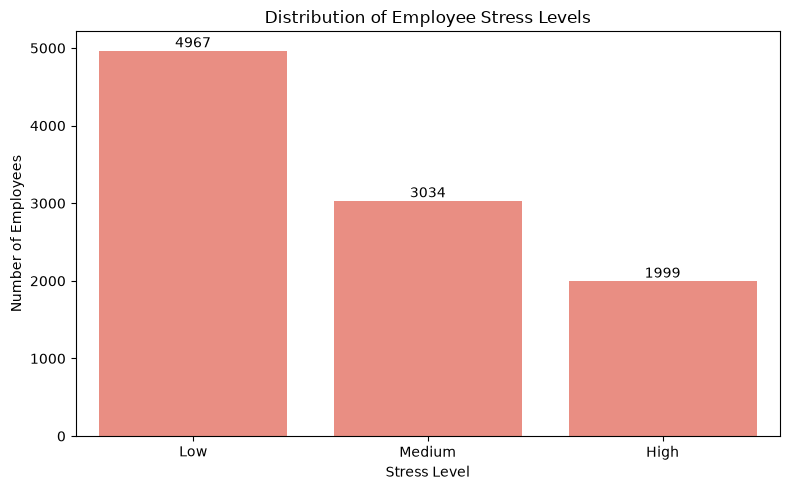

In [23]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Stress_Level",
    order=["Low", "Medium", "High"],
    color="salmon"
)

plt.title("Distribution of Employee Stress Levels")
plt.xlabel("Stress Level")
plt.ylabel("Number of Employees")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [24]:
stress_sentiment = (
    df.groupby("Stress_Level")["Sentiment_Score"]
    .mean()
    .reindex(["Low", "Medium", "High"])
)

print(stress_sentiment.round(3))

Stress_Level
Low       0.509
Medium    0.145
High     -0.099
Name: Sentiment_Score, dtype: float64


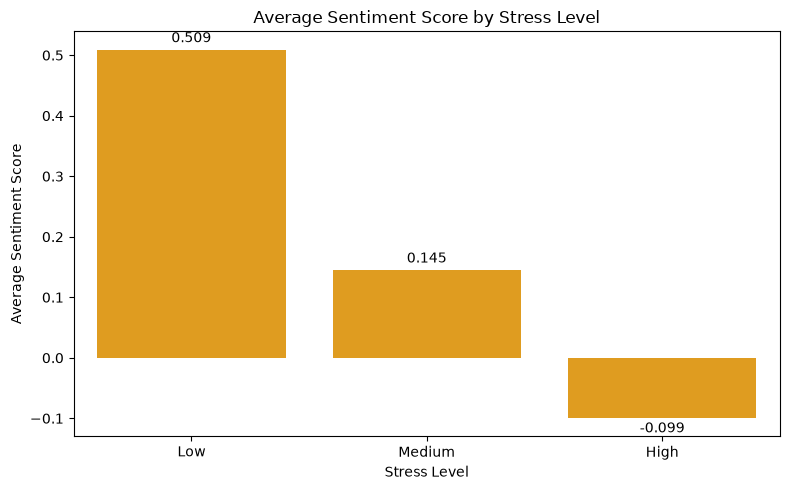

In [25]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=stress_sentiment.index,
    y=stress_sentiment.values,
    color="orange"
)

plt.title("Average Sentiment Score by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Average Sentiment Score")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

In [26]:
stress_mapping = {
    "Low": 1,
    "Medium": 2,
    "High": 3
}

df["Stress_Score"] = df[
    "Stress_Level"
].map(stress_mapping)

df[
    ["Stress_Level", "Stress_Score"]
].head()

,Stress_Level,Stress_Score
0,Low,1
1,Low,1
2,Medium,2
3,Low,1
4,Low,1


In [27]:
department_cluster_data = df.groupby(
    "Department"
).agg(
    Average_Sentiment=(
        "Sentiment_Score",
        "mean"
    ),
    
    Positive_Rate=(
        "Sentiment_Category",
        lambda x: (x == "Positive").mean() * 100
    ),
    
    Average_Stress=(
        "Stress_Score",
        "mean"
    )
).reset_index()

department_cluster_data.round(3)

,Department,Average_Sentiment,Positive_Rate,Average_Stress
0,Finance,0.264,56.739,1.724
1,HR,0.278,57.241,1.682
2,IT,0.284,58.216,1.712
3,Marketing,0.269,56.000,1.743
4,Sales,0.289,58.942,1.657


In [28]:
clustering_features = department_cluster_data[
    [
        "Average_Sentiment",
        "Positive_Rate",
        "Average_Stress"
    ]
]

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    clustering_features
)

In [29]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

department_cluster_data["Cluster"] = (
    kmeans.fit_predict(scaled_features)
)

department_cluster_data

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Department,Average_Sentiment,Positive_Rate,Average_Stress,Cluster
0,Finance,0.264351,56.739021,1.723877,1
1,HR,0.278454,57.240705,1.682485,2
2,IT,0.283579,58.215726,1.712198,2
3,Marketing,0.268995,56.000000,1.743077,1
4,Sales,0.289378,58.941695,1.657031,0


In [30]:
cluster_order = (
    department_cluster_data
    .groupby("Cluster")["Average_Sentiment"]
    .mean()
    .sort_values()
    .index
)

cluster_names = {
    cluster_order[0]: "Low Satisfaction",
    cluster_order[1]: "Medium Satisfaction",
    cluster_order[2]: "High Satisfaction"
}

department_cluster_data[
    "Satisfaction_Cluster"
] = department_cluster_data[
    "Cluster"
].map(cluster_names)

department_cluster_data.sort_values(
    by="Average_Sentiment",
    ascending=False
).round(3)

,Department,Average_Sentiment,Positive_Rate,Average_Stress,Cluster,Satisfaction_Cluster
4,Sales,0.289,58.942,1.657,0,High Satisfaction
2,IT,0.284,58.216,1.712,2,Medium Satisfaction
1,HR,0.278,57.241,1.682,2,Medium Satisfaction
3,Marketing,0.269,56.000,1.743,1,Low Satisfaction
0,Finance,0.264,56.739,1.724,1,Low Satisfaction


In [31]:
cluster_order = (
    department_cluster_data
    .groupby("Cluster")["Average_Sentiment"]
    .mean()
    .sort_values()
    .index
)

cluster_names = {
    cluster_order[0]: "Low Satisfaction",
    cluster_order[1]: "Medium Satisfaction",
    cluster_order[2]: "High Satisfaction"
}

department_cluster_data[
    "Satisfaction_Cluster"
] = department_cluster_data[
    "Cluster"
].map(cluster_names)

department_cluster_data.sort_values(
    by="Average_Sentiment",
    ascending=False
).round(3)

,Department,Average_Sentiment,Positive_Rate,Average_Stress,Cluster,Satisfaction_Cluster
4,Sales,0.289,58.942,1.657,0,High Satisfaction
2,IT,0.284,58.216,1.712,2,Medium Satisfaction
1,HR,0.278,57.241,1.682,2,Medium Satisfaction
3,Marketing,0.269,56.000,1.743,1,Low Satisfaction
0,Finance,0.264,56.739,1.724,1,Low Satisfaction


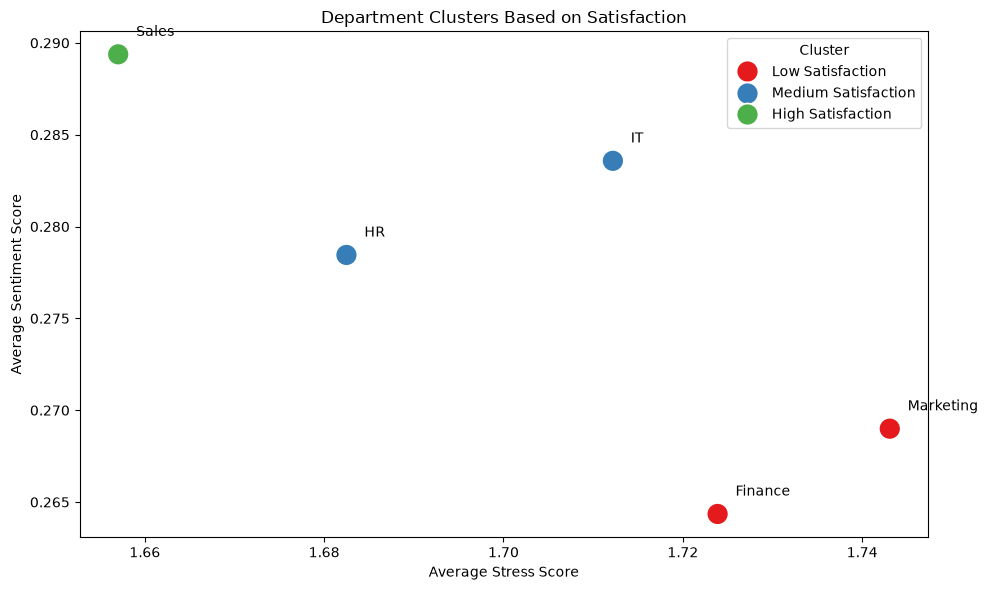

In [32]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=department_cluster_data,
    x="Average_Stress",
    y="Average_Sentiment",
    hue="Satisfaction_Cluster",
    s=250,
    palette="Set1"
)

for index, row in department_cluster_data.iterrows():
    plt.text(
        row["Average_Stress"] + 0.002,
        row["Average_Sentiment"] + 0.001,
        row["Department"]
    )

plt.title("Department Clusters Based on Satisfaction")
plt.xlabel("Average Stress Score")
plt.ylabel("Average Sentiment Score")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [33]:
correlation_data = df[
    [
        "Sentiment_Score",
        "Word_Count",
        "Stress_Score"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix.round(3)

,Sentiment_Score,Word_Count,Stress_Score
Sentiment_Score,1.000,-0.024,-0.653
Word_Count,-0.024,1.000,0.264
Stress_Score,-0.653,0.264,1.000


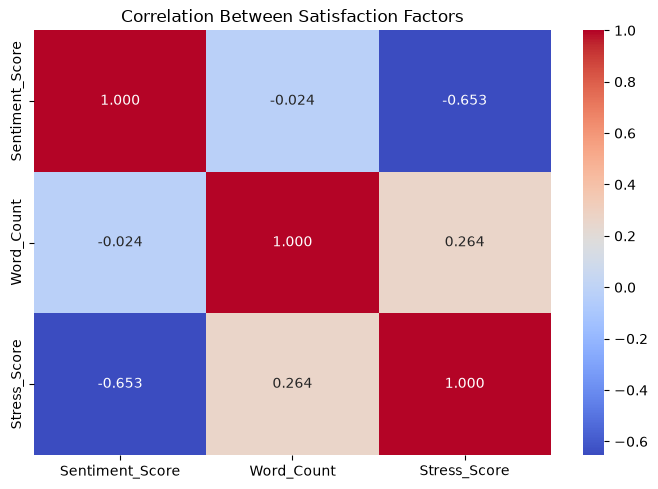

In [34]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".3f"
)

plt.title("Correlation Between Satisfaction Factors")
plt.tight_layout()
plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [36]:
X = df[
    [
        "Word_Count",
        "Employee_Role",
        "Department",
        "Stress_Level"
    ]
]

y = df["Sentiment_Score"]

In [37]:
numerical_columns = [
    "Word_Count"
]

categorical_columns = [
    "Employee_Role",
    "Department",
    "Stress_Level"
]

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            "passthrough",
            numerical_columns
        ),
        
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ]
)

In [39]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 8000
Testing records: 2000


In [40]:
model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        
        (
            "random_forest",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [41]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("Mean Absolute Error:", round(mae, 3))
print("R2 Score:", round(r2, 3))

Mean Absolute Error: 0.169
R2 Score: 0.594


In [42]:
feature_names = model[
    "preprocessor"
].get_feature_names_out()

feature_importance = model[
    "random_forest"
].feature_importances_

importance_table = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_table = importance_table.sort_values(
    by="Importance",
    ascending=False
)

importance_table.head(10)

,Feature,Importance
12,categorical__Stress_Level_Low,0.599727
0,numerical__Word_Count,0.298863
13,categorical__Stress_Level_Medium,0.079418
3,categorical__Employee_Role_Manager,0.002461
9,categorical__Department_Marketing,0.002376
2,categorical__Employee_Role_HR Specialist,0.002201
6,categorical__Department_Finance,0.002158
5,categorical__Employee_Role_Software Engineer,0.002156
7,categorical__Department_HR,0.002147
8,categorical__Department_IT,0.002040


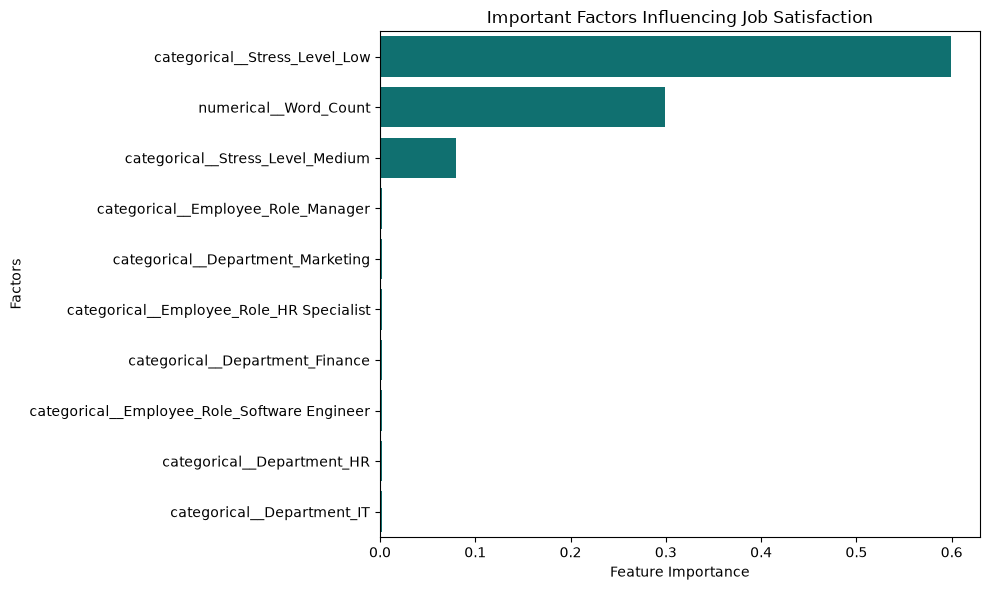

In [43]:
top_features = importance_table.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    color="teal"
)

plt.title("Important Factors Influencing Job Satisfaction")
plt.xlabel("Feature Importance")
plt.ylabel("Factors")
plt.tight_layout()
plt.show()

In [ ]:
print("FINAL TASK RESULTS")

print(
    "\nHighest satisfaction department:",
    highest_department
)

print(
    "Lowest satisfaction department:",
    lowest_department
)

print(
    "\nOverall average sentiment:",
    round(df["Sentiment_Score"].mean(), 3)
)

print(
    "Positive employee messages:",
    (df["Sentiment_Category"] == "Positive").sum()
)

print(
    "Neutral employee messages:",
    (df["Sentiment_Category"] == "Neutral").sum()
)

print(
    "Negative employee messages:",
    (df["Sentiment_Category"] == "Negative").sum()
)

print(
    "\nSentiment and stress correlation:",
    round(
        correlation_matrix.loc[
            "Sentiment_Score",
            "Stress_Score"
        ],
        3
    )
)